<a href="https://colab.research.google.com/github/ziyadabdulla/SupervisedLearning_CaseStudy/blob/main/Case_Study_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
training_data = '/content/drive/MyDrive/DSA/Anitha miss/ML/Supervised Learning Case Study/Training_data (1).csv'
testing_data = '/content/drive/MyDrive/DSA/Anitha miss/ML/Supervised Learning Case Study/Testing_data (1).csv'

df_train = pd.read_csv(training_data)
df_train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [6]:
df_train.shape

(5634, 21)

In [7]:
df_train.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [8]:
df_train.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [9]:
df_train.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [10]:
#duplicate values
df_train.duplicated().sum()

np.int64(0)

In [11]:
#Filling missing values in gender with mode
mode_gender = df_train['gender'].mode()[0]
df_train['gender'] = df_train['gender'].fillna(mode_gender)

In [12]:
df_train.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [13]:
mode_onlinesecurity = df_train['OnlineSecurity'].mode()[0]
df_train['OnlineSecurity'] = df_train['OnlineSecurity'].fillna(mode_onlinesecurity)

In [14]:
df_train.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
median_monthlycharge = df_train['MonthlyCharges'].median()
df_train['MonthlyCharges'] = df_train['MonthlyCharges'].fillna(median_monthlycharge)

In [16]:
df_train.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
df_train['TotalCharges'] = pd.to_numeric(df_train['TotalCharges'], errors='coerce')
median_totalcharges = df_train['TotalCharges'].median()
df_train['TotalCharges'] = df_train['TotalCharges'].fillna(median_totalcharges)

In [18]:
df_train.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
def find_outliers(column):
    Q1 = df_train[column].quantile(0.25)
    Q3 = df_train[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df_train[(df_train[column] < lower) | (df_train[column] > upper)]
    return lower,upper

#outliers in tenure
outliers_tenure = find_outliers('tenure')
print("Outliers in tenure:",len(outliers_tenure))

#outliers in monthly charges
outliers_monthlycharges = find_outliers('MonthlyCharges')
print("Outliers in monthly charges:",len(outliers_monthlycharges))

#outliers in total charges
outliers_totalcharges = find_outliers('TotalCharges')
print("Outliers in total charges:",len(outliers_totalcharges))

Outliers in tenure: 0
Outliers in monthly charges: 0
Outliers in total charges: 24


<Axes: xlabel='TotalCharges', ylabel='Count'>

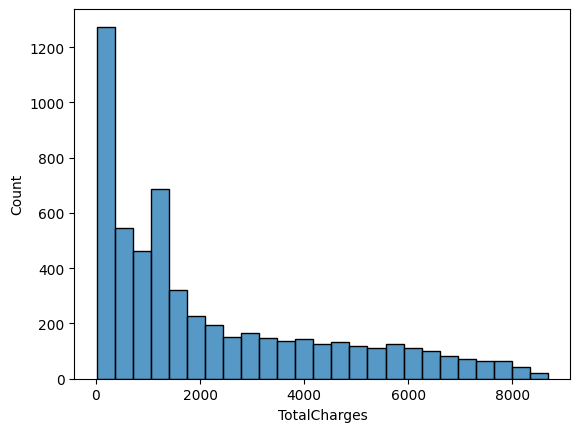

In [20]:
sns.histplot(df_train['TotalCharges'])

<Axes: ylabel='TotalCharges'>

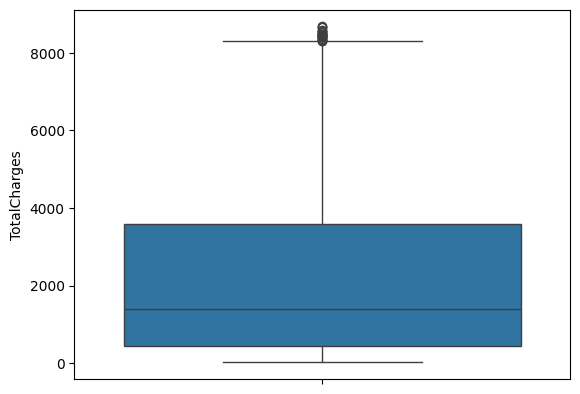

In [21]:
sns.boxplot(df_train['TotalCharges'])

In [22]:
#Handling the outliers in totalcharges
Q1 = df_train['TotalCharges'].quantile(0.25)
Q3 = df_train['TotalCharges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_train['TotalCharges'] = df_train['TotalCharges'].clip(lower_bound, upper_bound)

In [23]:
outliers_totalcharges = find_outliers('TotalCharges')
print("Outliers in total charges:",len(outliers_totalcharges))

Outliers in total charges: 0


In [24]:
#drop column customer id
df_train.drop('customerID',axis=1,inplace=True)

In [25]:
df_train['Contract'].value_counts()

,count
Contract,
Month-to-month,3094
Two year,1368
One year,1172


In [26]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder

le = LabelEncoder()
oe = OrdinalEncoder()
ohe = OneHotEncoder()

df_train['gender'] = le.fit_transform(df_train['gender'])
df_train['Partner'] = le.fit_transform(df_train['Partner'])
df_train['Dependents'] = le.fit_transform(df_train['Dependents'])
df_train['PhoneService'] = le.fit_transform(df_train['PhoneService'])
df_train['MultipleLines'] = oe.fit_transform(df_train[['MultipleLines']])
df_train['InternetService'] = oe.fit_transform(df_train[['InternetService']])
df_train['OnlineSecurity'] = oe.fit_transform(df_train[['OnlineSecurity']])
df_train['OnlineBackup'] = oe.fit_transform(df_train[['OnlineBackup']])
df_train['DeviceProtection'] = oe.fit_transform(df_train[['DeviceProtection']])
df_train['TechSupport'] = oe.fit_transform(df_train[['TechSupport']])
df_train['StreamingTV'] = oe.fit_transform(df_train[['StreamingTV']])
df_train['StreamingMovies'] = oe.fit_transform(df_train[['StreamingMovies']])
df_train['Contract'] = oe.fit_transform(df_train[['Contract']])
df_train['PaperlessBilling'] = le.fit_transform(df_train['PaperlessBilling'])
df_train['PaymentMethod'] = oe.fit_transform(df_train[['PaymentMethod']])
df_train['Churn'] = le.fit_transform(df_train['Churn'])

In [27]:
df_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,35,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,3.0,20.75,700.45,0
1,0,0,0,0,28,0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1,3.0,35.75,961.40,0
2,1,0,0,0,56,1,2.0,1.0,0.0,2.0,0.0,0.0,2.0,2.0,0.0,0,2.0,98.60,5581.05,0
3,1,0,1,0,39,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1,0.0,20.45,790.00,0
4,0,0,1,1,43,0,1.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,1.0,1,0.0,51.25,2151.60,0


In [28]:
df_train['CLV'] = df_train['tenure'] * df_train['MonthlyCharges']
df_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CLV
0,0,0,0,0,35,1,0.0,2.0,1.0,1.0,...,1.0,1.0,1.0,1.0,0,3.0,20.75,700.45,0,726.25
1,0,0,0,0,28,0,1.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,1,3.0,35.75,961.40,0,1001.00
2,1,0,0,0,56,1,2.0,1.0,0.0,2.0,...,0.0,2.0,2.0,0.0,0,2.0,98.60,5581.05,0,5521.60
3,1,0,1,0,39,1,0.0,2.0,1.0,1.0,...,1.0,1.0,1.0,2.0,1,0.0,20.45,790.00,0,797.55
4,0,0,1,1,43,0,1.0,0.0,0.0,2.0,...,2.0,2.0,0.0,1.0,1,0.0,51.25,2151.60,0,2203.75


In [29]:
#Splitting data
from sklearn.model_selection import train_test_split
y = df_train['Churn']
x = df_train.drop(columns=['Churn'])
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

pd.Series(y_train).value_counts()

(4507, 20) (1127, 20) (4507,) (1127,)


,count
Churn,
0,3327
1,1180


In [30]:
#Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges','CLV']
x_train[cols_to_scale] = sc.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = sc.transform(x_test[cols_to_scale])
x_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,CLV
4082,1,0,1,1,0.709857,1,2.0,1.0,2.0,2.0,2.0,0.0,2.0,2.0,1.0,1,2.0,1.481060,1.462544,1.398600
1728,1,1,0,0,-0.957030,1,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0,3.0,-0.551720,-0.803478,-0.825962
2795,0,0,0,0,-1.200965,1,0.0,1.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,1,2.0,1.124764,-0.863771,-0.892703
334,1,0,0,0,0.140676,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,-1.544873,-0.690733,-0.696240
3625,0,1,0,0,-0.103259,0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,1,2.0,-0.858100,-0.473794,-0.482991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,1,0,1,0,0.221988,1,2.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,1.0,0,1.0,0.129890,0.206672,0.149503
5191,1,1,1,1,1.441661,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0,0.0,-1.574134,-0.464427,-0.430619
5226,0,0,1,1,0.872480,1,2.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0,0.0,-0.179933,0.481541,0.426135
5390,1,0,0,0,-1.200965,1,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,1,2.0,0.141938,-0.372167,-0.931042


In [31]:
x_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,CLV
2121,1,0,1,0,1.197726,1,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,1.0,-1.427829,-0.349273,-0.365042
915,1,0,0,0,1.482317,1,2.0,1.0,0.0,2.0,2.0,2.0,2.0,0.0,2.0,1,1.0,1.116158,2.059185,1.991860
2585,1,0,1,1,0.913136,1,2.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,1,1.0,0.866579,1.311469,1.201421
787,0,0,0,0,-1.241620,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1,3.0,-1.556922,-0.988542,-1.006265
101,0,0,0,0,-1.241620,1,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1,2.0,0.186691,-0.941594,-0.960921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4416,0,0,1,0,0.181332,1,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1,0.0,-1.562086,-0.372167,-0.695412
1954,1,0,1,1,1.604284,1,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0,0.0,1.697936,2.769662,2.667662
1616,1,0,0,0,-0.347193,1,0.0,1.0,2.0,0.0,0.0,0.0,2.0,2.0,0.0,1,2.0,1.011163,0.031020,-0.007882
3807,0,0,1,1,-0.997686,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,2.0,-0.680813,-0.819915,-0.861414


In [32]:
#import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score,confusion_matrix

In [33]:
#Logistic Regression Model
lr = LogisticRegression()
lr.fit(x_train,y_train)
lr_pred = lr.predict(x_test)

In [34]:
#check accuracy score and confusion matrix
print(accuracy_score(y_test,lr_pred))
print(confusion_matrix(y_test,lr_pred))

0.7923691215616682
[[709  94]
 [140 184]]


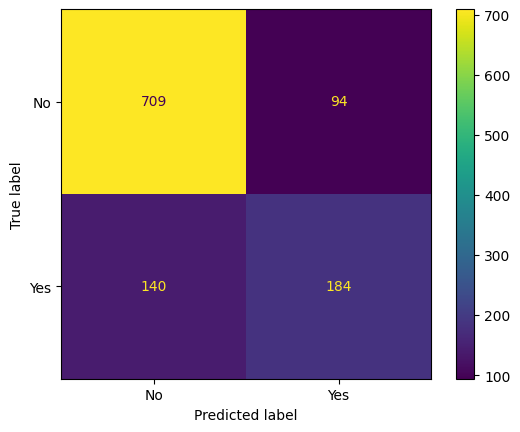

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,lr_pred,display_labels=le.classes_)
plt.show()

In [36]:
#Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train)
y_pred_rf = rf_model.predict(x_test)

print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))


0.7781721384205856
[[720  83]
 [167 157]]


In [37]:
#knn
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
y_pred_knn = knn_model.predict(x_test)

print(accuracy_score(y_test,y_pred_knn))
print(confusion_matrix(y_test,y_pred_knn))

0.7497781721384206
[[679 124]
 [158 166]]


**Best Model is Logistic Regression Model - 79%+ accuracy**

In [38]:
#Tuning Hyper Parameters of Logistic Regression Model
lr.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    'penalty': ['l1', 'l2'],
    'C': loguniform(0.001, 100),
    'solver': ['liblinear'],
    'max_iter': [1000],
    'class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'C': np.float64(1.0907475835157696), 'class_weight': None, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score: 0.8014202007623951


# Testing data

In [40]:
df_test = pd.read_csv(testing_data)
df_test.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [41]:
df_test.shape # df_test is used as the complete test set, without further train/validation splitting.

(1409, 21)

In [42]:
df_test.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [46]:
def find_outliers_test(column):
    Q1 = df_test[column].quantile(0.25)
    Q3 = df_test[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df_test[(df_test[column] < lower) | (df_test[column] > upper)]

df_test['TotalCharges'] = pd.to_numeric(df_test['TotalCharges'], errors='coerce')
df_test['TotalCharges'] = df_test['TotalCharges'].fillna(median_totalcharges)

#outliers in tenure
outliers_tenure_test = find_outliers_test('tenure')
print("Outliers in tenure:",len(outliers_tenure_test))

#outliers in monthly charges
outliers_monthlycharges_test = find_outliers_test('MonthlyCharges')
print("Outliers in monthly charges:",len(outliers_monthlycharges_test))

#outliers in total charges
outliers_totalcharges_test = find_outliers_test('TotalCharges')
print("Outliers in total charges:",len(outliers_totalcharges_test))

Outliers in tenure: 0
Outliers in monthly charges: 0
Outliers in total charges: 0


In [47]:
#drop column customer id
df_test.drop('customerID',axis=1,inplace=True)

In [48]:
df_test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.30,No
1,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,Male,0,No,No,43,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,Female,0,No,No,10,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374.00,No


In [49]:
df_test['gender'] = le.fit_transform(df_test['gender'])
df_test['Partner'] = le.fit_transform(df_test['Partner'])
df_test['Dependents'] = le.fit_transform(df_test['Dependents'])
df_test['PhoneService'] = le.fit_transform(df_test['PhoneService'])
df_test['MultipleLines'] = oe.fit_transform(df_test[['MultipleLines']])
df_test['InternetService'] = oe.fit_transform(df_test[['InternetService']])
df_test['OnlineSecurity'] = oe.fit_transform(df_test[['OnlineSecurity']])
df_test['OnlineBackup'] = oe.fit_transform(df_test[['OnlineBackup']])
df_test['DeviceProtection'] = oe.fit_transform(df_test[['DeviceProtection']])
df_test['TechSupport'] = oe.fit_transform(df_test[['TechSupport']])
df_test['StreamingTV'] = oe.fit_transform(df_test[['StreamingTV']])
df_test['StreamingMovies'] = oe.fit_transform(df_test[['StreamingMovies']])
df_test['Contract'] = oe.fit_transform(df_test[['Contract']])
df_test['PaperlessBilling'] = le.fit_transform(df_test['PaperlessBilling'])
df_test['PaymentMethod'] = oe.fit_transform(df_test[['PaymentMethod']])
df_test['Churn'] = le.fit_transform(df_test['Churn'])

In [50]:
df_test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,1,1,40,1,2.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1,2.0,81.20,3292.30,0
1,0,0,1,0,12,1,2.0,0.0,2.0,0.0,2.0,0.0,2.0,2.0,1.0,0,2.0,78.85,876.75,0
2,1,0,0,0,43,1,2.0,1.0,0.0,0.0,0.0,2.0,2.0,2.0,1.0,1,2.0,100.00,4211.55,1
3,1,0,0,0,72,1,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1,2.0,118.20,8547.15,0
4,0,0,0,0,10,0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0,2.0,36.25,374.00,0


In [51]:
df_test['CLV'] = df_test['tenure'] * df_test['MonthlyCharges']

In [54]:
# Applying the best logistic regression model to the test dataset

# Separating features and target from df_test
X_test_final = df_test.drop(columns=['Churn'])
y_test_final = df_test['Churn']

X_test_final['TotalCharges'] = pd.to_numeric(X_test_final['TotalCharges'], errors='coerce')
X_test_final['TotalCharges'] = X_test_final['TotalCharges'].fillna(median_totalcharges)

# Scaling
X_test_final[cols_to_scale] = sc.transform(X_test_final[cols_to_scale])

y_pred_tuned_lr = random_search.best_estimator_.predict(X_test_final)

print("Tuned Logistic Regression Accuracy on Test Data:", accuracy_score(y_test_final, y_pred_tuned_lr))

Tuned Logistic Regression Accuracy on Test Data: 0.8097941802696949
